This notebook is to display and compare the results for batch invalidation. As a summary, it seems like batch invalidation gives a slight improvement for the tail latencies, but usually performs around the same compared to baseline MuCache.

## Import libraries

In [22]:
import matplotlib.pyplot as plt

In [23]:
# Quick code to load json files and get stats
import json
import re
def getStats( filename ):
    with open( filename, 'r') as file:
        data = json.load(file)

    X = []
    response50 = []
    response95 = []
    hitrate = []
    throughput = []
    for key in data:
        X.append( key )

        key_data = data[key]
        raw = key_data["raw"]

        # print( raw )
        match = re.search(r'/.*50\.00\% in (\d+\.\d+) secs.*95\.00\% in (\d+\.\d+) secs', raw, flags = re.DOTALL)
        response50.append( float( match.group(1) ) * 1000 )
        response95.append( float( match.group(2) ) * 1000 )

        if( "hit_rate" in key_data ):
            hitrate.append( key_data["hit_rate"] )
        throughput.append( key_data["throughput"] )

    out = {"50": response50, "95":response95,"hit_rate":hitrate,"throughput":throughput}
    return X, out

In [24]:
def plotStats( X, plots, xLabel, yLabel, title, log_scale = False, i = 0, ylim = -1 ):

    for label, plot in plots:
        if( i == 0 ):
            plt.plot(X, plot, label=label )
        else:
            plt.plot(X[:i], plot[:i], label=label)

    if( log_scale ):
        plt.yscale( "log" )
        plt.ylabel( yLabel + " (Log Scaled)" )
    else:
        if( ylim > 0 ):
            plt.ylim(0, ylim)
        plt.ylabel(yLabel)
    plt.grid()
    plt.xlabel(xLabel)
    plt.title(title)
    plt.legend()
    plt.show()
    

## Real World Applications

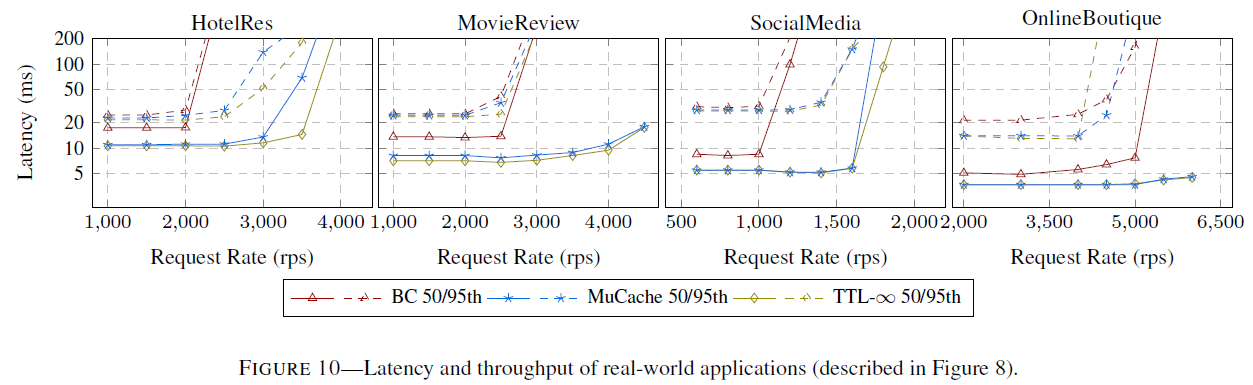

In [26]:
# HotelRes REDO
# x, bc_out = getStats( "hotel-baseline-1000hotelsize-5000app-12proxy-4zmq.json" )
# _, mucache_out = getStats( "hotel-1000hotelsize-5000app-12proxy-4zmq.json" )
# _, ttl_out = getStats( "hotel-upper-1000hotelsize-5000app-12proxy-4zmq.json" )
# _, batch_out = getStats( "hotel-batch-1000hotelsize-5000app-12proxy-4zmq.json" )

# plots = [["MuCache 50", mucache_out["50"]],
#          ["MuCache 95", mucache_out["95"]],
#          ["BC 50", bc_out["50"]],
#          ["BC 95", bc_out["95"]],
#          # ["TTL 50", ttl_out["50"]],
#          # ["TTL 95", ttl_out["95"]],
#          ["Batch 50", batch_out["50"]],
#          ["Batch 95", batch_out["95"]]]

# plotStats( x, plots, "Request Rate (rps)", "Latency (ms)", "Hotel", ylim = 100 )

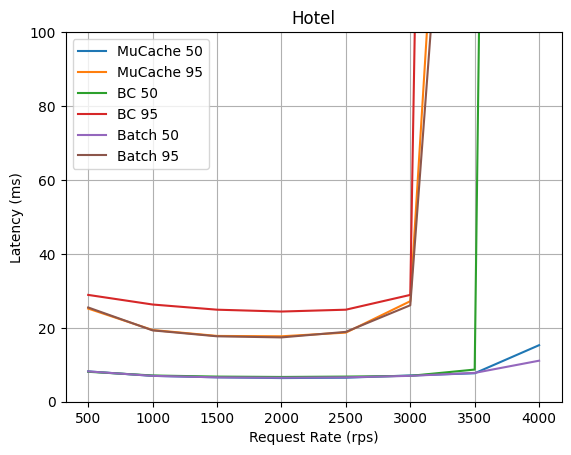

In [41]:
x, bc_out = getStats( "hotel-baseline-1000hotelsize-5000app-12proxy-1zmq-writeHeavy.json" )
_, mucache_out = getStats( "hotel-1000hotelsize-5000app-12proxy-1zmq-writeHeavy.json" )
#_, ttl_out = getStats( "hotel-upper-1000hotelsize-5000app-12proxy-4zmq.json" )
_, batch_out = getStats( "hotel-batch-1000hotelsize-5000app-12proxy-1zmq-writeHeavy.json" )

plots = [["MuCache 50", mucache_out["50"]],
         ["MuCache 95", mucache_out["95"]],
         ["BC 50", bc_out["50"]],
         ["BC 95", bc_out["95"]],
         # ["TTL 50", ttl_out["50"]],
         # ["TTL 95", ttl_out["95"]],
         ["Batch 50", batch_out["50"]],
         ["Batch 95", batch_out["95"]]]

plotStats( x, plots, "Request Rate (rps)", "Latency (ms)", "Hotel", ylim = 100 )

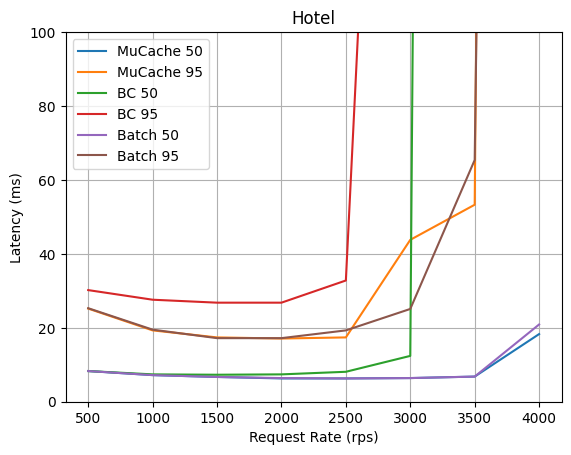

In [52]:
x, bc_out = getStats( "hotel-baseline-1000hotelsize-5000app-12proxy-1zmq-writeHeavyHotKeys.json" )
_, mucache_out = getStats( "hotel-1000hotelsize-5000app-12proxy-1zmq-writeHeavyHotKeys.json" )
#_, ttl_out = getStats( "hotel-upper-1000hotelsize-5000app-12proxy-4zmq.json" )
_, batch_out = getStats( "hotel-batch-1000hotelsize-5000app-12proxy-1zmq-writeHeavyHotKeys.json" )

plots = [["MuCache 50", mucache_out["50"]],
         ["MuCache 95", mucache_out["95"]],
         ["BC 50", bc_out["50"]],
         ["BC 95", bc_out["95"]],
         # ["TTL 50", ttl_out["50"]],
         # ["TTL 95", ttl_out["95"]],
         ["Batch 50", batch_out["50"]],
         ["Batch 95", batch_out["95"]]]

plotStats( x, plots, "Request Rate (rps)", "Latency (ms)", "Hotel", ylim = 100 )

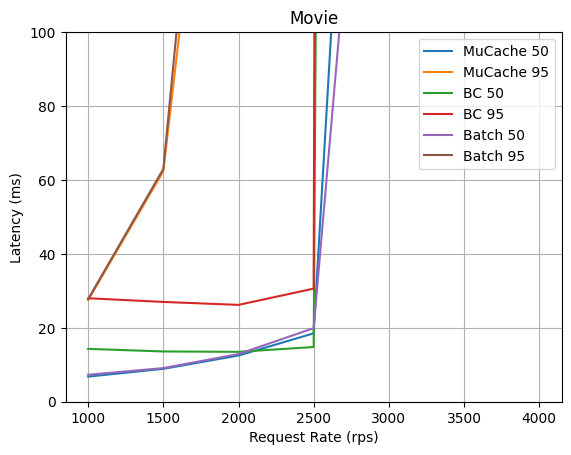

In [42]:
# MovieReview
x, bc_out = getStats( "movie-baseline-5000app-12proxy-1zmq.json" )
_, mucache_out = getStats( "movie-5000app-12proxy-1zmq.json" )
#_, ttl_out = getStats( "movie-upper-5000app-12proxy-4zmq.json" )
_, batch_out = getStats( "movie-batch-5000app-12proxy-1zmq.json" )

plots = [["MuCache 50", mucache_out["50"]],
         ["MuCache 95", mucache_out["95"]],
         ["BC 50", bc_out["50"]],
         ["BC 95", bc_out["95"]],
         # ["TTL 50", ttl_out["50"]],
         # ["TTL 95", ttl_out["95"]],
         ["Batch 50", batch_out["50"]],
         ["Batch 95", batch_out["95"]]]

plotStats( x, plots, "Request Rate (rps)", "Latency (ms)", "Movie", ylim = 100 )

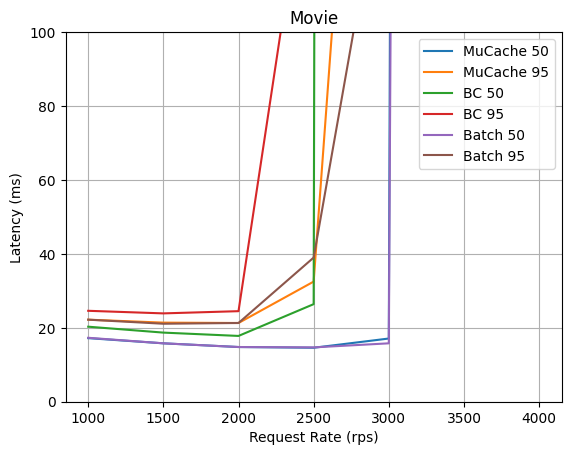

In [54]:
# MovieReview
x, bc_out = getStats( "movie-baseline-5000app-12proxy-1zmq-writeHeavyHotKeys.json" )
_, mucache_out = getStats( "movie-5000app-12proxy-1zmq-writeHeavyHotKeys.json" )
#_, ttl_out = getStats( "movie-upper-5000app-12proxy-4zmq.json" )
_, batch_out = getStats( "movie-batch-5000app-12proxy-1zmq-writeHeavyHotKeys.json" )

plots = [["MuCache 50", mucache_out["50"]],
         ["MuCache 95", mucache_out["95"]],
         ["BC 50", bc_out["50"]],
         ["BC 95", bc_out["95"]],
         # ["TTL 50", ttl_out["50"]],
         # ["TTL 95", ttl_out["95"]],
         ["Batch 50", batch_out["50"]],
         ["Batch 95", batch_out["95"]]]

plotStats( x, plots, "Request Rate (rps)", "Latency (ms)", "Movie", ylim = 100 )

In [ ]:
# MovieReview
x, bc_out = getStats( "movie-baseline-5000app-12proxy-1zmq-writeHeavy.json" )
_, mucache_out = getStats( "movie-5000app-12proxy-1zmq-writeHeavy.json" )
#_, ttl_out = getStats( "movie-upper-5000app-12proxy-4zmq.json" )
_, batch_out = getStats( "movie-batch-5000app-12proxy-1zmq-writeHeavy.json" )

plots = [["MuCache 50", mucache_out["50"]],
         ["MuCache 95", mucache_out["95"]],
         ["BC 50", bc_out["50"]],
         ["BC 95", bc_out["95"]],
         # ["TTL 50", ttl_out["50"]],
         # ["TTL 95", ttl_out["95"]],
         ["Batch 50", batch_out["50"]],
         ["Batch 95", batch_out["95"]]]

plotStats( x, plots, "Request Rate (rps)", "Latency (ms)", "Movie", ylim = 100 )

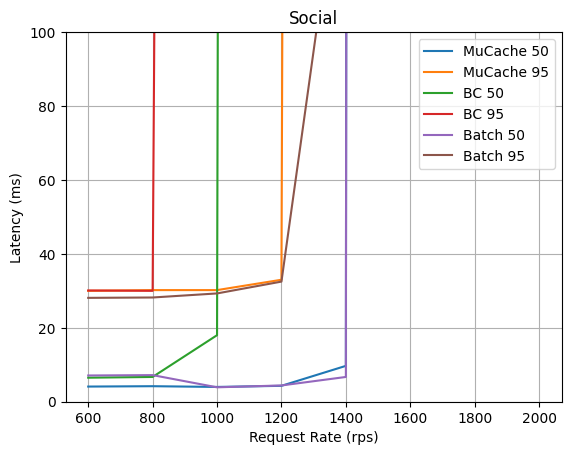

In [13]:
# SocialMedia
x, bc_out = getStats( "social-baseline-5000app-12proxy-4zmq.json" )
_, mucache_out = getStats( "social-5000app-12proxy-4zmq.json" )
_, ttl_out = getStats( "social-upper-5000app-12proxy-4zmq.json" )
_, batch_out = getStats( "social-batch-5000app-12proxy-4zmq.json" )

plots = [["MuCache 50", mucache_out["50"]],
         ["MuCache 95", mucache_out["95"]],
         ["BC 50", bc_out["50"]],
         ["BC 95", bc_out["95"]],
         # ["TTL 50", ttl_out["50"]],
         # ["TTL 95", ttl_out["95"]],
         ["Batch 50", batch_out["50"]],
         ["Batch 95", batch_out["95"]]]

plotStats( x, plots, "Request Rate (rps)", "Latency (ms)", "Social", ylim = 100 )

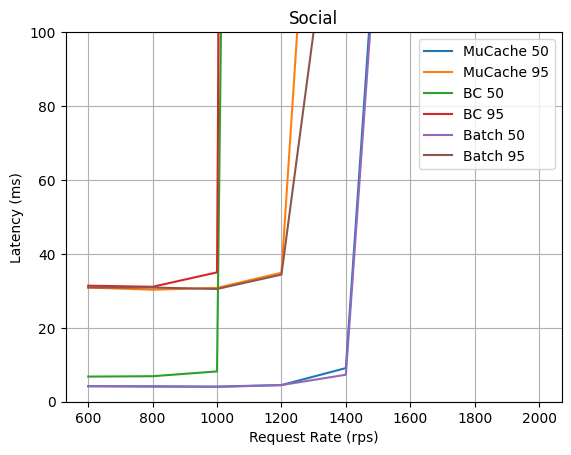

In [30]:
# SocialMedia
x, bc_out = getStats( "social-baseline-5000app-12proxy-1zmq.json" )
_, mucache_out = getStats( "social-5000app-12proxy-1zmq.json" )
_, batch_out = getStats( "social-batch-5000app-12proxy-1zmq.json" )

plots = [["MuCache 50", mucache_out["50"]],
         ["MuCache 95", mucache_out["95"]],
         ["BC 50", bc_out["50"]],
         ["BC 95", bc_out["95"]],
         # ["TTL 50", ttl_out["50"]],
         # ["TTL 95", ttl_out["95"]],
         ["Batch 50", batch_out["50"]],
         ["Batch 95", batch_out["95"]]]

plotStats( x, plots, "Request Rate (rps)", "Latency (ms)", "Social", ylim = 100 )

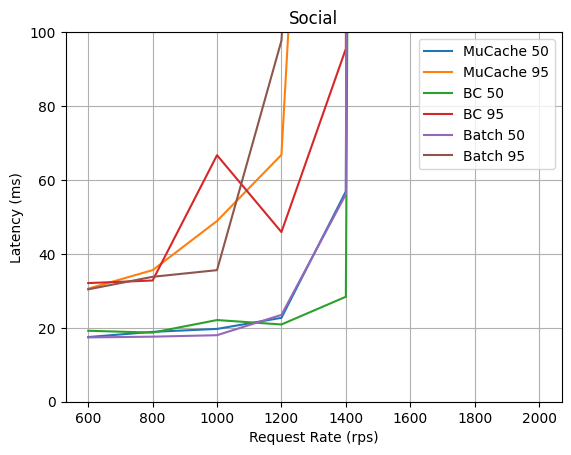

In [51]:
# SocialMedia
x, bc_out = getStats( "social-baseline-5000app-12proxy-1zmq-writeHeavyHotKeys.json" )
_, mucache_out = getStats( "social-5000app-12proxy-1zmq-writeHeavyHotKeys.json" )
_, batch_out = getStats( "social-batch-5000app-12proxy-1zmq-writeHeavyHotKeys.json" )

plots = [["MuCache 50", mucache_out["50"]],
         ["MuCache 95", mucache_out["95"]],
         ["BC 50", bc_out["50"]],
         ["BC 95", bc_out["95"]],
         # ["TTL 50", ttl_out["50"]],
         # ["TTL 95", ttl_out["95"]],
         ["Batch 50", batch_out["50"]],
         ["Batch 95", batch_out["95"]]]

plotStats( x, plots, "Request Rate (rps)", "Latency (ms)", "Social", ylim = 100 )

In [ ]:
# SocialMedia
x, bc_out = getStats( "social-baseline-5000app-12proxy-1zmq-writeHeavy.json" )
_, mucache_out = getStats( "social-5000app-12proxy-1zmq-writeHeavy.json" )
_, batch_out = getStats( "social-batch-5000app-12proxy-1zmq-writeHeavy.json" )

plots = [["MuCache 50", mucache_out["50"]],
         ["MuCache 95", mucache_out["95"]],
         ["BC 50", bc_out["50"]],
         ["BC 95", bc_out["95"]],
         # ["TTL 50", ttl_out["50"]],
         # ["TTL 95", ttl_out["95"]],
         ["Batch 50", batch_out["50"]],
         ["Batch 95", batch_out["95"]]]

plotStats( x, plots, "Request Rate (rps)", "Latency (ms)", "Social", ylim = 100 )

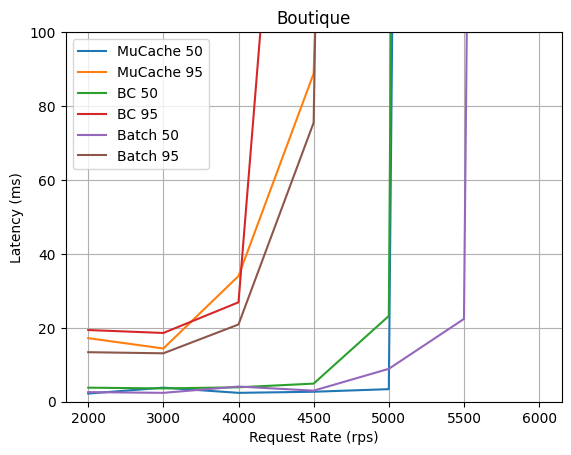

In [15]:
# OnlineBoutique (REDO)
x, bc_out = getStats( "boutique-baseline-halfSize-5000app-12proxy-4zmq-2.json" )
_, mucache_out = getStats( "boutique-halfSize-5000app-12proxy-4zmq-2.json" )
_, ttl_out = getStats( "boutique-upper-halfSize-5000app-12proxy-4zmq-2.json" )
_, batch_out = getStats( "boutique-batch-halfSize-5000app-12proxy-4zmq-2.json" )
#_, prefetch_out = getStats( "boutique-prefetch-halfSize-5000app-12proxy-4zmq-2.json" )

plots = [["MuCache 50", mucache_out["50"]],
         ["MuCache 95", mucache_out["95"]],
         ["BC 50", bc_out["50"]],
         ["BC 95", bc_out["95"]],
         # ["TTL 50", ttl_out["50"]],
         # ["TTL 95", ttl_out["95"]],
         ["Batch 50", batch_out["50"]],
         ["Batch 95", batch_out["95"]],]
         # ["Prefetch 50", prefetch_out["50"]],
         # ["Prefetch 95", prefetch_out["95"]]]

plotStats( x, plots, "Request Rate (rps)", "Latency (ms)", "Boutique", ylim = 100)

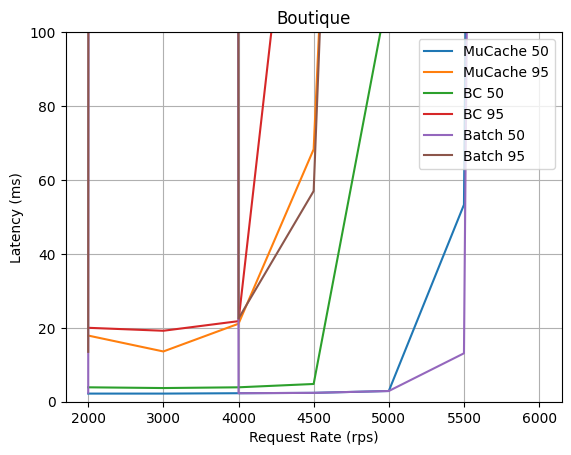

In [53]:
# OnlineBoutique (REDO)
x, bc_out = getStats( "boutique-baseline-halfProductSize-5000app-12proxy-1zmq.json" )
_, mucache_out = getStats( "boutique-halfProductSize-5000app-12proxy-1zmq.json" )
#_, ttl_out = getStats( "boutique-upper-halfSize-5000app-12proxy-4zmq-2.json" )
_, batch_out = getStats( "boutique-batch-halfProductSize-5000app-12proxy-1zmq.json" )
#_, prefetch_out = getStats( "boutique-prefetch-halfSize-5000app-12proxy-4zmq-2.json" )

plots = [["MuCache 50", mucache_out["50"]],
         ["MuCache 95", mucache_out["95"]],
         ["BC 50", bc_out["50"]],
         ["BC 95", bc_out["95"]],
         # ["TTL 50", ttl_out["50"]],
         # ["TTL 95", ttl_out["95"]],
         ["Batch 50", batch_out["50"]],
         ["Batch 95", batch_out["95"]],]
         # ["Prefetch 50", prefetch_out["50"]],
         # ["Prefetch 95", prefetch_out["95"]]]

plotStats( x, plots, "Request Rate (rps)", "Latency (ms)", "Boutique", ylim = 100 )

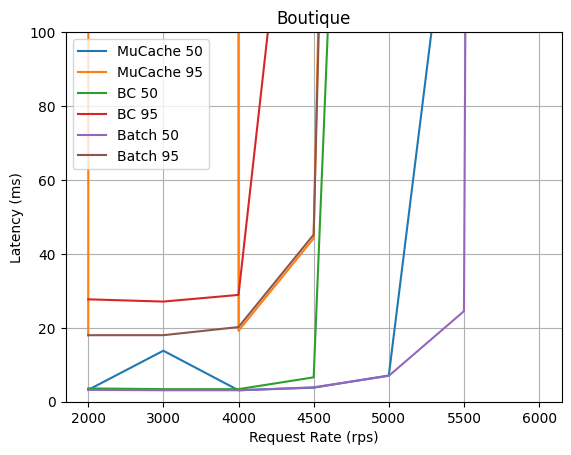

In [40]:
# OnlineBoutique (REDO)
x, bc_out = getStats( "boutique-baseline-halfProductSize-5000app-12proxy-1zmq-writeHeavy.json" )
_, mucache_out = getStats( "boutique-halfProductSize-5000app-12proxy-1zmq-writeHeavy.json" )
#_, ttl_out = getStats( "boutique-upper-halfSize-5000app-12proxy-4zmq-2.json" )
_, batch_out = getStats( "boutique-batch-halfProductSize-5000app-12proxy-1zmq-writeHeavy.json" )
#_, prefetch_out = getStats( "boutique-prefetch-halfSize-5000app-12proxy-4zmq-2.json" )

plots = [["MuCache 50", mucache_out["50"]],
         ["MuCache 95", mucache_out["95"]],
         ["BC 50", bc_out["50"]],
         ["BC 95", bc_out["95"]],
         # ["TTL 50", ttl_out["50"]],
         # ["TTL 95", ttl_out["95"]],
         ["Batch 50", batch_out["50"]],
         ["Batch 95", batch_out["95"]],]
         # ["Prefetch 50", prefetch_out["50"]],
         # ["Prefetch 95", prefetch_out["95"]]]

plotStats( x, plots, "Request Rate (rps)", "Latency (ms)", "Boutique", ylim = 100 )

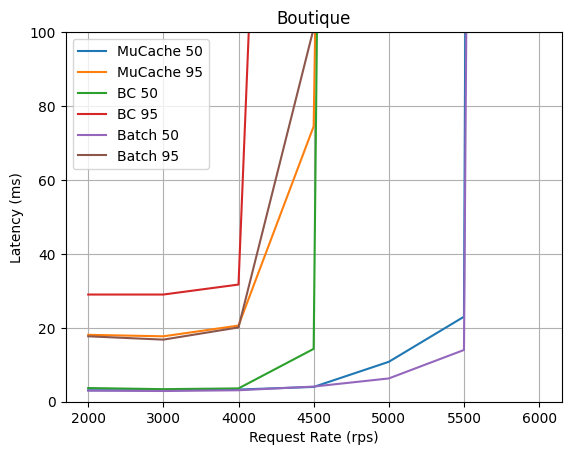

In [48]:
# OnlineBoutique (REDO)
x, bc_out = getStats( "boutique-baseline-halfProductSize-5000app-12proxy-1zmq-writeHeavyHotKeys.json" )
_, mucache_out = getStats( "boutique-halfProductSize-5000app-12proxy-1zmq-writeHeavyHotKeys.json" )
#_, ttl_out = getStats( "boutique-upper-halfSize-5000app-12proxy-4zmq-2.json" )
_, batch_out = getStats( "boutique-batch-halfProductSize-5000app-12proxy-1zmq-writeHeavyHotKeys.json" )
#_, prefetch_out = getStats( "boutique-prefetch-halfSize-5000app-12proxy-4zmq-2.json" )

plots = [["MuCache 50", mucache_out["50"]],
         ["MuCache 95", mucache_out["95"]],
         ["BC 50", bc_out["50"]],
         ["BC 95", bc_out["95"]],
         # ["TTL 50", ttl_out["50"]],
         # ["TTL 95", ttl_out["95"]],
         ["Batch 50", batch_out["50"]],
         ["Batch 95", batch_out["95"]],]
         # ["Prefetch 50", prefetch_out["50"]],
         # ["Prefetch 95", prefetch_out["95"]]]

plotStats( x, plots, "Request Rate (rps)", "Latency (ms)", "Boutique", ylim = 100 )

### Analysis
From the results, we can see that using batch invalidation matches the performance of MuCache. Though there are trends that the latency spikes occur slightly later as well as lower latency in total at the 95 tail-latencies. Thus, we can say that batch invalidation does slightly improve performance, but not by much. 

DIDNT DO, DO IT